# Complete Linear Algebra Project (Updated & Exam Ready)

Student Performance Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, det, inv, eig, svd
from scipy.linalg import lu
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

df = pd.read_csv('student_performance.csv')
df.head()


,StudentID,StudentName,Category,Math,Science,English,History,Computer_Science,Physics,Chemistry,Average
0,S001,Student_193,Below Average,57,61,68,58,56,47,43,55.71
1,S002,Student_212,Below Average,67,65,32,58,66,42,50,54.29
2,S003,Student_148,Below Average,49,42,54,60,36,45,54,48.57
3,S004,Student_049,Above Average,73,81,75,93,100,92,100,87.71
4,S005,Student_189,Below Average,39,66,55,34,39,31,35,42.71


## Part A - Vector Fundamentals

In [3]:
subjects=['Math','Science','English','History','Computer_Science','Physics','Chemistry']
X=df[subjects]

v1=X.iloc[0].values
v2=X.iloc[1].values

print('Vector 1 =',v1)
print('Vector 2 =',v2)

print('Norm-1 =',norm(v1,1))
print('Norm-2 =',norm(v1,2))

dot=np.dot(v1,v2)
print('Dot Product =',dot)

cos_theta = dot/(norm(v1)*norm(v2))
angle=np.degrees(np.arccos(cos_theta))
print('Angle Between Vectors =',angle)

print('Cross Product =',np.cross(v1[:3],v2[:3]))


Vector 1 = [57 61 68 58 56 47 43]
Vector 2 = [67 65 32 58 66 42 50]
Norm-1 = 390.0
Norm-2 = 148.83547964111244
Dot Product = 21144
Angle Between Vectors = 15.442679868469664
Cross Product = [-2468  2732  -382]


In [4]:
projection=(np.dot(v1,v2)/np.dot(v2,v2))*v2
print('Projection of Vector 1 onto Vector 2:')
print(projection)


Projection of Vector 1 onto Vector 2:
[65.21719915 63.27041709 31.14851303 56.45667986 64.24380812 40.88242335
 48.66955161]


## Part B - Matrix Operations

In [5]:
A=X.iloc[:7,:7].values
B=X.iloc[7:14,:7].values

print('Matrix Addition')
print(A+B)

print('\nMatrix Multiplication')
print(A@B)

print('\nTranspose')
print(A.T)

d=det(A)
print('\nDeterminant =',d)

if abs(d)>1e-10:
    print('\nInverse Matrix')
    print(inv(A))
else:
    print('Matrix is singular. Inverse not possible.')


Matrix Addition
[[103 103 109 126  95  81  84]
 [133 117  98 106 114  73 105]
 [118 109 133 143 106 124 125]
 [141 141 137 132 133 150 136]
 [100 114 110  99  71  90  70]
 [110 124 141 100 122 146 150]
 [131 109 145  99 145 151 134]]

Matrix Multiplication
[[24058 21528 24633 22918 20630 23145 20956]
 [22882 20014 23115 21348 19053 21287 19256]
 [20761 18588 21551 19307 18426 20587 18305]
 [37535 33411 38754 34668 33058 37420 32885]
 [18482 16321 19095 17478 15986 17194 16255]
 [19637 17689 20873 18924 18513 20187 18219]
 [34146 30725 35382 32508 30918 34073 30877]]

Transpose
[[ 57  67  49  73  39  39  84]
 [ 61  65  42  81  66  40  79]
 [ 68  32  54  75  55  69  79]
 [ 58  58  60  93  34  33  66]
 [ 56  66  36 100  39  35  77]
 [ 47  42  45  92  31  47  90]
 [ 43  50  54 100  35  58  86]]

Determinant = -38062850830.00008

Inverse Matrix
[[ 0.00872706  0.02954499  0.0018697  -0.02945798 -0.02531906  0.01504143
   0.01169866]
 [-0.0267804  -0.00992457  0.01091301  0.00233164  0.045042

## Part C - Linear Transformation & Geometry

- Line → 1 Dimension
- Plane → 2 Dimensions
- 3D Space → 3 Dimensions
- Hyperplane → (n−1) Dimensions in n-D space

Since the dataset contains 7 subject features, every student can be represented as a point in 7D space.


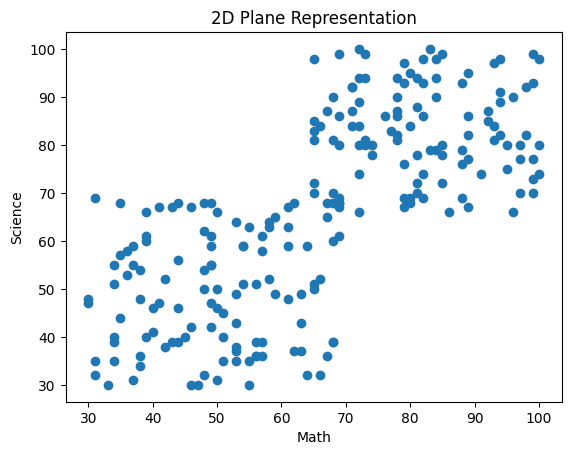

In [6]:
plt.scatter(df['Math'],df['Science'])
plt.xlabel('Math')
plt.ylabel('Science')
plt.title('2D Plane Representation')
plt.show()


## Part D - Eigenvalues, LU and SVD

In [7]:
cov=np.cov(X.T)
eigenvalues,eigenvectors=eig(cov)

print('Eigenvalues')
print(eigenvalues)

print('\nEigenvectors')
print(eigenvectors)


Eigenvalues
[1999.89559008   88.35121018  103.922446    109.74130415  126.83299744
  142.44153742  140.42315467]

Eigenvectors
[[ 0.37557745  0.6042064   0.52565501  0.20020852 -0.103804   -0.40678429
   0.03508322]
 [ 0.38958456 -0.377581    0.49629219 -0.14386127  0.62178787  0.21682402
   0.07086356]
 [ 0.37378732 -0.50108639 -0.24408613 -0.01536888 -0.07770485 -0.71704653
  -0.17084338]
 [ 0.38400961 -0.31456246  0.20118545  0.23840492 -0.68186047  0.43376102
  -0.05650012]
 [ 0.37767006  0.31058944 -0.2862704  -0.19368316  0.13555141  0.24548089
  -0.75020035]
 [ 0.36088755  0.11650493 -0.48605101  0.62650202  0.28727901  0.14360838
   0.35253908]
 [ 0.38355001  0.17969669 -0.24316848 -0.6724057  -0.17529808  0.06576704
   0.52372076]]


In [8]:
P,L,U=lu(A)

print('L Matrix')
print(L)

print('\nU Matrix')
print(U)


L Matrix
[[ 1.          0.          0.          0.          0.          0.
   0.        ]
 [ 0.46428571  1.          0.          0.          0.          0.
   0.        ]
 [ 0.79761905  0.06780349  1.          0.          0.          0.
   0.        ]
 [ 0.86904762  0.42103126  0.04243347  1.          0.          0.
   0.        ]
 [ 0.58333333 -0.13926106 -0.32455124  0.6948282   1.          0.
   0.        ]
 [ 0.46428571  0.11327649 -0.93774074  0.19954922  0.11460772  1.
   0.        ]
 [ 0.67857143  0.25213155 -0.30301352  0.40933396  0.29885546  0.88355661
   1.        ]]

U Matrix
[[ 84.          79.          79.          66.          77.
   90.          86.        ]
 [  0.          29.32142857  18.32142857   3.35714286   3.25
  -10.78571429  -4.92857143]
 [  0.           0.         -32.25416159   5.12951685   4.36297199
  -29.0544052  -18.26106374]
 [  0.           0.           0.          34.01173183  31.52984567
   19.55971652  28.11186778]
 [  0.           0.           0.   

In [9]:
U1,S,Vt=svd(X,full_matrices=False)

print('Singular Values')
print(S)


Singular Values
[2683.09668436  176.62043644  175.44438475  166.66764284  155.31104894
  151.20402666  139.14520791]


## Part E - PCA

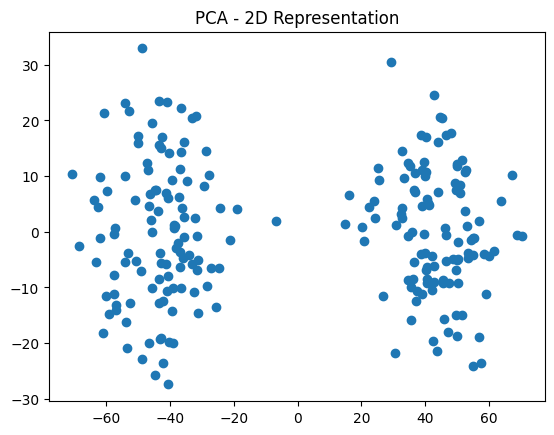

Explained Variance Ratio
[0.73753117 0.05253028]


In [10]:
pca=PCA(n_components=2)
Xp=pca.fit_transform(X)

plt.scatter(Xp[:,0],Xp[:,1])
plt.title('PCA - 2D Representation')
plt.show()

print('Explained Variance Ratio')
print(pca.explained_variance_ratio_)


## LDA

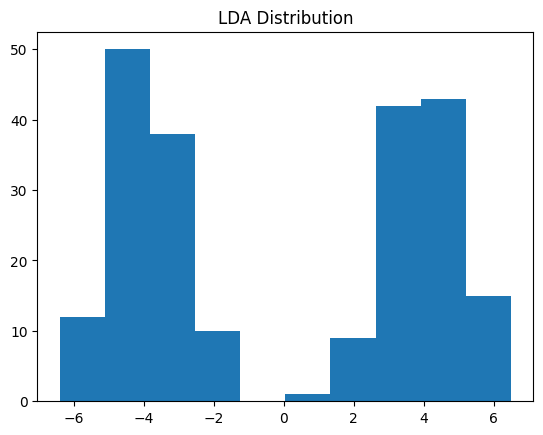

Category
Below Average    110
Above Average    110
Name: count, dtype: int64


In [11]:
lda=LDA(n_components=1)
Xl=lda.fit_transform(X,df['Category'])

plt.hist(Xl)
plt.title('LDA Distribution')
plt.show()

print(df['Category'].value_counts())


## Conclusion

Completed:
- Vector Representation
- Norm-1 and Norm-2
- Dot Product
- Angle Between Vectors
- Cross Product
- Projection
- Matrix Operations
- Eigenvalues & Eigenvectors
- LU Decomposition
- SVD
- PCA
- LDA

Interpretation:
- PCA reduces dimensions while preserving variance.
- LDA separates Above Average and Below Average students.
- Eigenvalues indicate variance captured by principal directions.
